In [1]:
import os
os.environ['PYTHON_FROZEN_MODULES'] = 'off'
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('/kaggle/input/datasets/marcomiracapillo/alibaba-400-machine/machines_sample_400.csv')
df.head()


df["ds"] = pd.to_datetime(df["time_stamp"], unit="s")
df = df.sort_values(["machine_id", "ds"])

dfs_resampled = []

# raggruppo per macchina
for machine_id, df_m in df.groupby('machine_id'):
    # raggruppo per intervalli di 5min e interpolo i valori mancanti
    df_m = df_m.set_index('ds').sort_index()
    numeric_cols = df_m.select_dtypes(include='number').columns
    df_m_resampled = df_m[numeric_cols].resample('5min').mean()
    df_m_resampled = df_m_resampled.interpolate(method='linear', limit_direction='both')
    
    df_m_resampled['machine_id'] = machine_id
    df_m_resampled = df_m_resampled.reset_index()
    dfs_resampled.append(df_m_resampled)

df_resampled = pd.concat(dfs_resampled, ignore_index=True)

# normalizzazione della colonna target della previsione (media 0, stdv 1)
cpu_mean = df_resampled["cpu_util_percent"].mean()
cpu_std  = df_resampled["cpu_util_percent"].std()
df_resampled["cpu_norm"] = (df_resampled["cpu_util_percent"] - cpu_mean) / cpu_std

df_resampled.head()



,ds,time_stamp,cpu_util_percent,mem_util_percent,mem_gps,mkpi,net_in,net_out,disk_io_percent,machine_id,cpu_norm
0,1970-01-01 00:00:00,147.500000,10.750000,84.250000,8.92,1.333333,32.467500,23.090,1.250000,m_1,-1.759342
1,1970-01-01 00:05:00,423.000000,22.600000,87.600000,8.92,1.333333,32.470000,23.098,4.200000,m_1,-0.984655
2,1970-01-01 00:10:00,786.250000,25.000000,84.125000,8.92,1.333333,32.470000,23.100,3.125000,m_1,-0.827756
3,1970-01-01 00:15:00,1095.714286,30.428571,86.714286,8.92,1.333333,32.480000,23.100,4.285714,m_1,-0.472866
4,1970-01-01 00:20:00,1358.888889,26.111111,87.000000,8.92,1.333333,32.481111,23.110,2.888889,m_1,-0.755118


In [3]:
df.head()

,machine_id,time_stamp,cpu_util_percent,mem_util_percent,mem_gps,mkpi,net_in,net_out,disk_io_percent,ds
4007461,m_1,10,13,84,NaN,NaN,32.46,23.09,1,1970-01-01 00:00:10
1276857,m_1,130,11,85,NaN,NaN,32.47,23.09,1,1970-01-01 00:02:10
1276858,m_1,190,9,84,NaN,NaN,32.47,23.09,1,1970-01-01 00:03:10
1276859,m_1,260,10,84,NaN,NaN,32.47,23.09,2,1970-01-01 00:04:20
4007462,m_1,310,12,85,NaN,NaN,32.47,23.09,2,1970-01-01 00:05:10


In [4]:
class MultiStepCPUDataset(Dataset):
    def __init__(self, df, input_window=30, horizon=10):
        # per ogni macchina estraggo la finestra di input e il target, le cui dimensioni dipendono dai valori che passo alla classe
        # tensori del tipo 
        # x: [num_samples, input_window, 1] dove 1 è il num di feature
        # y: [num_samples, horizon]
        self.X = []
        self.y = []

        for _, df_m in df.groupby("machine_id"):
            series = df_m["cpu_norm"].values

            if len(series) < input_window + horizon:
                continue

            for i in range(len(series) - input_window - horizon):
                self.X.append(series[i:i+input_window])
                self.y.append(series[i+input_window:i+input_window+horizon])

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32).unsqueeze(-1)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [5]:
INPUT_TIME=2*60
INPUT_WINDOW = int(INPUT_TIME/5)
HORIZON_TIME=1*60
HORIZON = int(HORIZON_TIME/5)
BATCH_SIZE = 512

dataset = MultiStepCPUDataset(df_resampled, INPUT_WINDOW, HORIZON)

indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(indices, test_size=0.2, shuffle=True)

train_ds = torch.utils.data.Subset(dataset, train_idx)
val_ds   = torch.utils.data.Subset(dataset, val_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE)


In [6]:
class LSTMForecast(nn.Module):
    def __init__(self, hidden=256, layers=3, horizon=30, recency_bias=2.0):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden,
            num_layers=layers,
            batch_first=True
        )
        self.attn = nn.Linear(hidden, 1)
        self.recency_bias = recency_bias
        self.fc = nn.Linear(hidden, horizon)

    def forward(self, x):
        out, _ = self.lstm(x)
        if hasattr(self, "attn"):
            scores = self.attn(out).squeeze(-1)
        else:
            scores = torch.zeros(out.size(0), out.size(1), device=out.device)
        positions = torch.linspace(0.0, 1.0, steps=out.size(1), device=out.device).unsqueeze(0)
        recency_bias = getattr(self, "recency_bias", 2.0)
        scores = scores + recency_bias * positions
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(out * weights.unsqueeze(-1), dim=1)
        return self.fc(context)


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMForecast(horizon=HORIZON).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()


In [8]:
EPOCHS = 75
train_losses = [] #
val_losses = []   #

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device) #

        optimizer.zero_grad()
        pred = model(x) #
        loss = criterion(pred, y) #
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Calcola la media della loss per l'epoca di training
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device) #
            pred = model(x)
            val_loss += criterion(pred, y).item()

    # Calcola la media della loss per l'epoca di validazione
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch:02d} | Train {avg_train_loss:.4f} | Val {avg_val_loss:.4f}")


Epoch 00 | Train 0.2588 | Val 0.2322
Epoch 01 | Train 0.2232 | Val 0.2158
Epoch 02 | Train 0.2034 | Val 0.1960
Epoch 03 | Train 0.1882 | Val 0.1840
Epoch 04 | Train 0.1765 | Val 0.1753
Epoch 05 | Train 0.1669 | Val 0.1687
Epoch 06 | Train 0.1588 | Val 0.1612
Epoch 07 | Train 0.1519 | Val 0.1543
Epoch 08 | Train 0.1455 | Val 0.1501
Epoch 09 | Train 0.1399 | Val 0.1452
Epoch 10 | Train 0.1347 | Val 0.1412
Epoch 11 | Train 0.1308 | Val 0.1368
Epoch 12 | Train 0.1261 | Val 0.1345
Epoch 13 | Train 0.1221 | Val 0.1316
Epoch 14 | Train 0.1188 | Val 0.1279
Epoch 15 | Train 0.1155 | Val 0.1253
Epoch 16 | Train 0.1129 | Val 0.1222
Epoch 17 | Train 0.1102 | Val 0.1200
Epoch 18 | Train 0.1079 | Val 0.1175
Epoch 19 | Train 0.1057 | Val 0.1166
Epoch 20 | Train 0.1045 | Val 0.1147
Epoch 21 | Train 0.1017 | Val 0.1126
Epoch 22 | Train 0.0999 | Val 0.1110
Epoch 23 | Train 0.0985 | Val 0.1105
Epoch 24 | Train 0.0970 | Val 0.1084
Epoch 25 | Train 0.0956 | Val 0.1071
Epoch 26 | Train 0.0942 | Val 0.1062
E

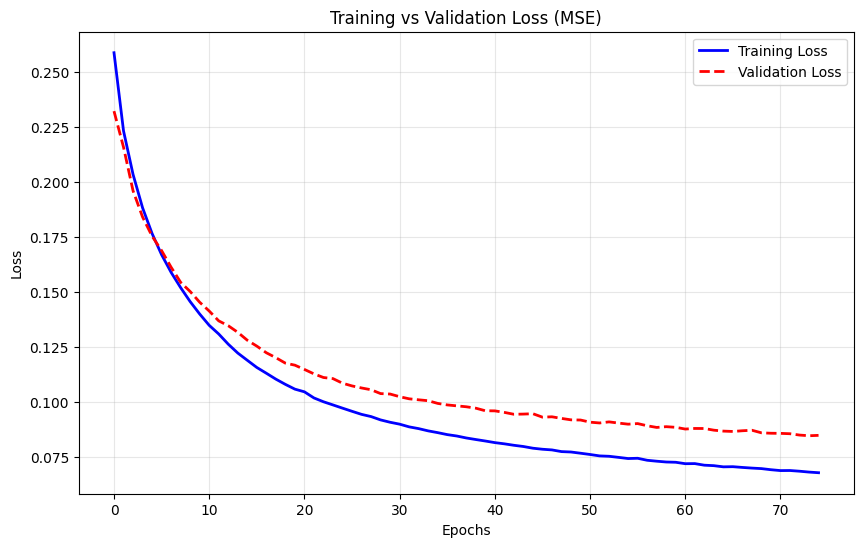

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.title('Training vs Validation Loss (MSE)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

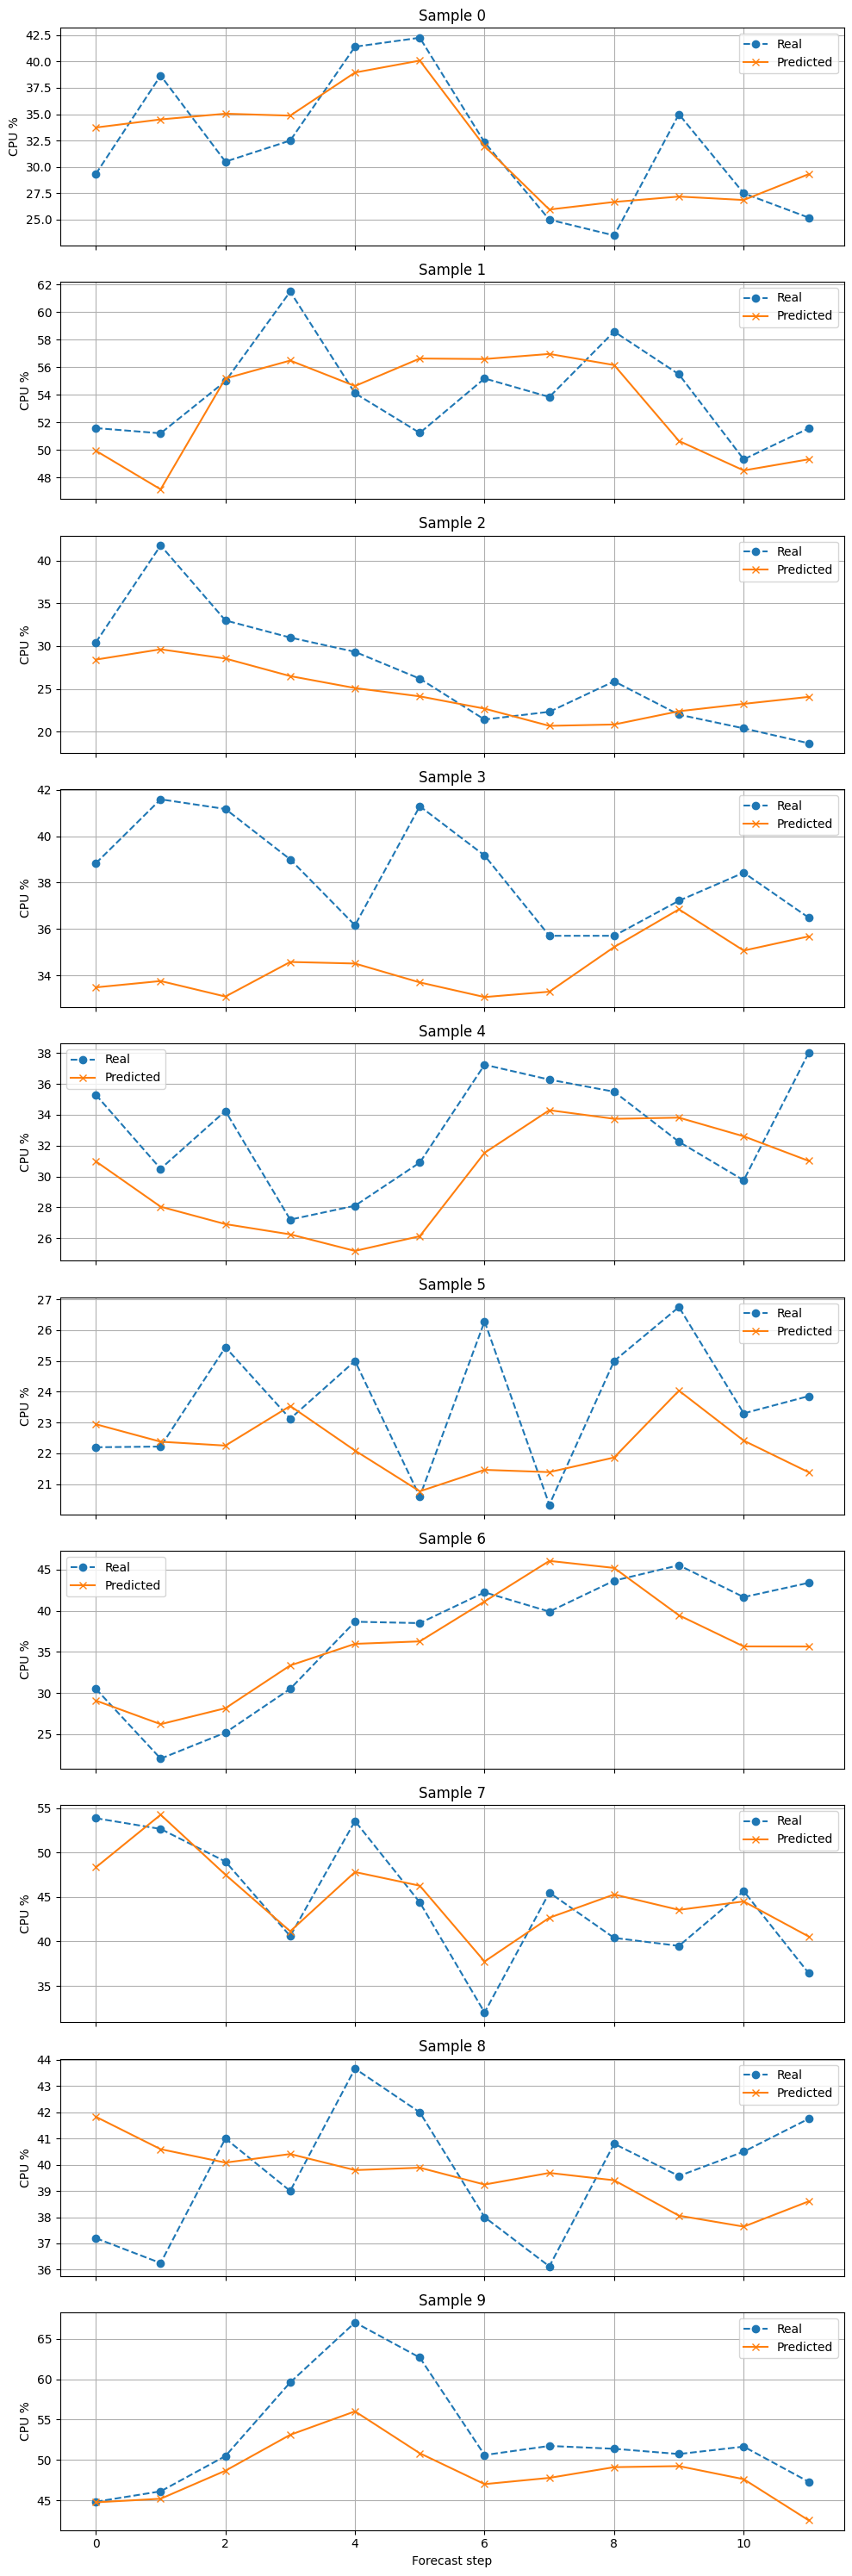

In [10]:
model.eval()

x_val, y_val = next(iter(val_loader))
x_val = x_val.to(device)

with torch.no_grad():
    y_pred = model(x_val).cpu().numpy()

y_true = y_val.numpy()

# de-normalizzazione
y_pred = y_pred * cpu_std + cpu_mean
y_true = y_true * cpu_std + cpu_mean

# numero di sample da plottare
n_samples = 10
fig, axes = plt.subplots(n_samples, 1, figsize=(10, 3*n_samples), sharex=True)

for i in range(n_samples):
    ax = axes[i]
    ax.plot(y_true[i], label="Real", linestyle='--', marker='o')
    ax.plot(y_pred[i], label="Predicted", linestyle='-', marker='x')
    ax.set_title(f"Sample {i}")
    ax.set_ylabel("CPU %")
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("Forecast step")
plt.tight_layout()
plt.show()


In [11]:
# salva modello
torch.save(model, "lstm_cpu_model_full.pt")

In [12]:
INPUT_TIME=2*60
INPUT_WINDOW = int(INPUT_TIME/5)
HORIZON_TIME=1*60
HORIZON = int(HORIZON_TIME/5)
BATCH_SIZE = 512
def forecast_cpu(model, cpu_series, window=30):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval()

    x = torch.tensor(cpu_series[-window:], dtype=torch.float32)
    x = ((x - cpu_mean) / cpu_std).unsqueeze(0).unsqueeze(-1).to(device)

    with torch.no_grad():
        pred = model(x).cpu().numpy()[0]

    return pred * cpu_std + cpu_mean


In [13]:
# carica modello
model = torch.load(
    "lstm_cpu_model_full.pt",
    weights_only=False,
)
model


LSTMForecast(
  (lstm): LSTM(1, 256, num_layers=3, batch_first=True)
  (attn): Linear(in_features=256, out_features=1, bias=True)
  (fc): Linear(in_features=256, out_features=12, bias=True)
)

In [14]:
series = df[df.machine_id == "m_949"].copy()

series["ds"] = pd.to_datetime(series["time_stamp"], unit="s")

series = (
    series[['ds', 'cpu_util_percent']]
    .set_index('ds')
    .sort_index()
    .resample('5min')
    .mean()
    .interpolate(method='linear', limit_direction='both')
)

series


,cpu_util_percent
ds,
1970-01-01 00:10:00,28.250000
1970-01-01 00:15:00,35.000000
1970-01-01 00:20:00,28.777778
1970-01-01 00:25:00,31.250000
1970-01-01 00:30:00,23.818182
...,...
1970-01-08 23:35:00,35.000000
1970-01-08 23:40:00,26.285714
1970-01-08 23:45:00,26.500000


In [15]:
WINDOW_ID= 0
start = WINDOW_ID
end_x = start + INPUT_WINDOW
end_y = end_x + HORIZON

x = series[start : start + INPUT_WINDOW]
y = series[start + INPUT_WINDOW : start + INPUT_WINDOW + HORIZON]
print(len(x))
print(len(y))


24
12


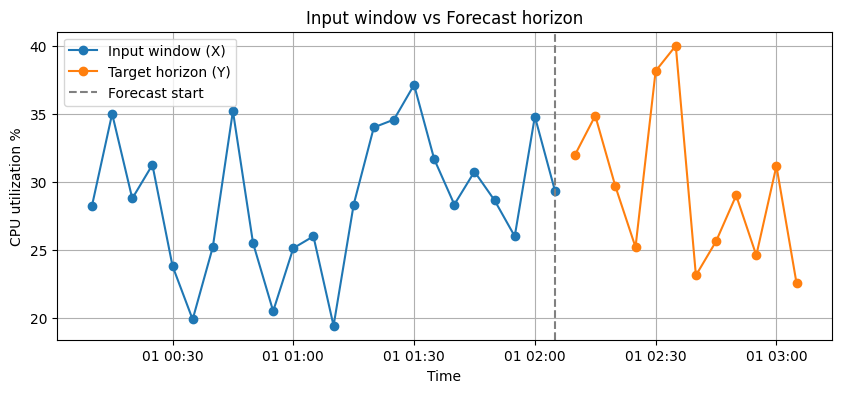

In [16]:
plt.figure(figsize=(10, 4))

plt.plot(x.index, x["cpu_util_percent"], label="Input window (X)", marker="o")
plt.plot(y.index, y["cpu_util_percent"], label="Target horizon (Y)", marker="o")

plt.axvline(
    x.index[-1],
    color="gray",
    linestyle="--",
    label="Forecast start"
)

plt.title("Input window vs Forecast horizon")
plt.xlabel("Time")
plt.ylabel("CPU utilization %")
plt.legend()
plt.grid(True)
plt.show()

Next steps CPU forecast length: 12


/tmp/ipykernel_23/3183925955.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  x = torch.tensor(cpu_series[-window:], dtype=torch.float32)


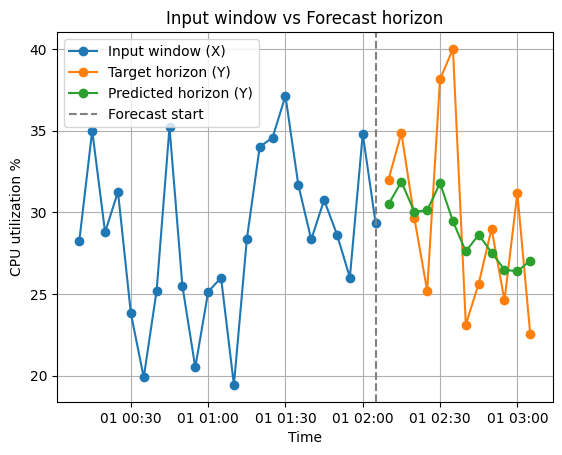

In [17]:
future_cpu = forecast_cpu(model, x['cpu_util_percent'], INPUT_WINDOW)


print("Next steps CPU forecast length:", len(future_cpu))

plt.plot(x.index, x["cpu_util_percent"], label="Input window (X)", marker="o")
plt.plot(y.index, y["cpu_util_percent"], label="Target horizon (Y)", marker="o")
plt.plot(y.index, future_cpu, label="Predicted horizon (Y)", marker="o")

plt.axvline(
    x.index[-1],
    color="gray",
    linestyle="--",
    label="Forecast start"
)

plt.title("Input window vs Forecast horizon")
plt.xlabel("Time")
plt.ylabel("CPU utilization %")
plt.legend()
plt.grid(True)
plt.show()
